# Project Rough-Regime: Computational Analysis & Validation

**Authors:** Quantitative Research Team  
**Date:** 2025

This notebook reproduces all empirical results for the paper *'Rough Volatility Arbitrage under Markov Regime Switching: A Volterra Process Approach'*. Each section corresponds to a figure in the manuscript.

---
| Section | Content | Key Output |
|---------|---------|------------|
| §1 | Roughness Calibration | fBM paths + Realized Vol |
| §2 | Volterra Convergence | Log-error vs Log-N plot |
| §3 | Regime Detection | HMM Regime Map |
| §4 | Strategy Performance | Equity curve + Drawdown |
| §5 | Transaction Costs | Sharpe Ratio Heatmap |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import norm as sp_norm
from scipy.special import gamma as gamma_fn
from numba import njit
import math

# ── Plotting style ──────────────────────────────────────────────────
PALETTE = {'calm': '#2196F3', 'turbulent': '#F44336',
           'naive': '#90A4AE', 'regime': '#4CAF50', 'accent': '#FF9800'}

plt.rcParams.update({
    'figure.dpi': 140,
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
})

RNG = np.random.default_rng(42)
print('Environment ready.')

Environment ready.


---
## §1  Roughness Calibration: Fractional Brownian Motion

Fractional Brownian motion $B^H_t$ generalises standard Brownian motion via the Hurst exponent $H \in (0,1)$:

$$\mathbb{E}\bigl[B^H_t B^H_s\bigr] = \tfrac{1}{2}\bigl(t^{2H} + s^{2H} - |t-s|^{2H}\bigr)$$

- $H = 0.5$: standard Brownian motion (independent increments)  
- $H < 0.5$: **rough** / anti-persistent (empirical SPX: $H \approx 0.07$)  
- $H > 0.5$: persistent / trending

Paths are simulated using the **Davies–Harte exact spectral method** (circulant embedding).

The time complexity: $O(n \log N)$ for a sample of size $N$.


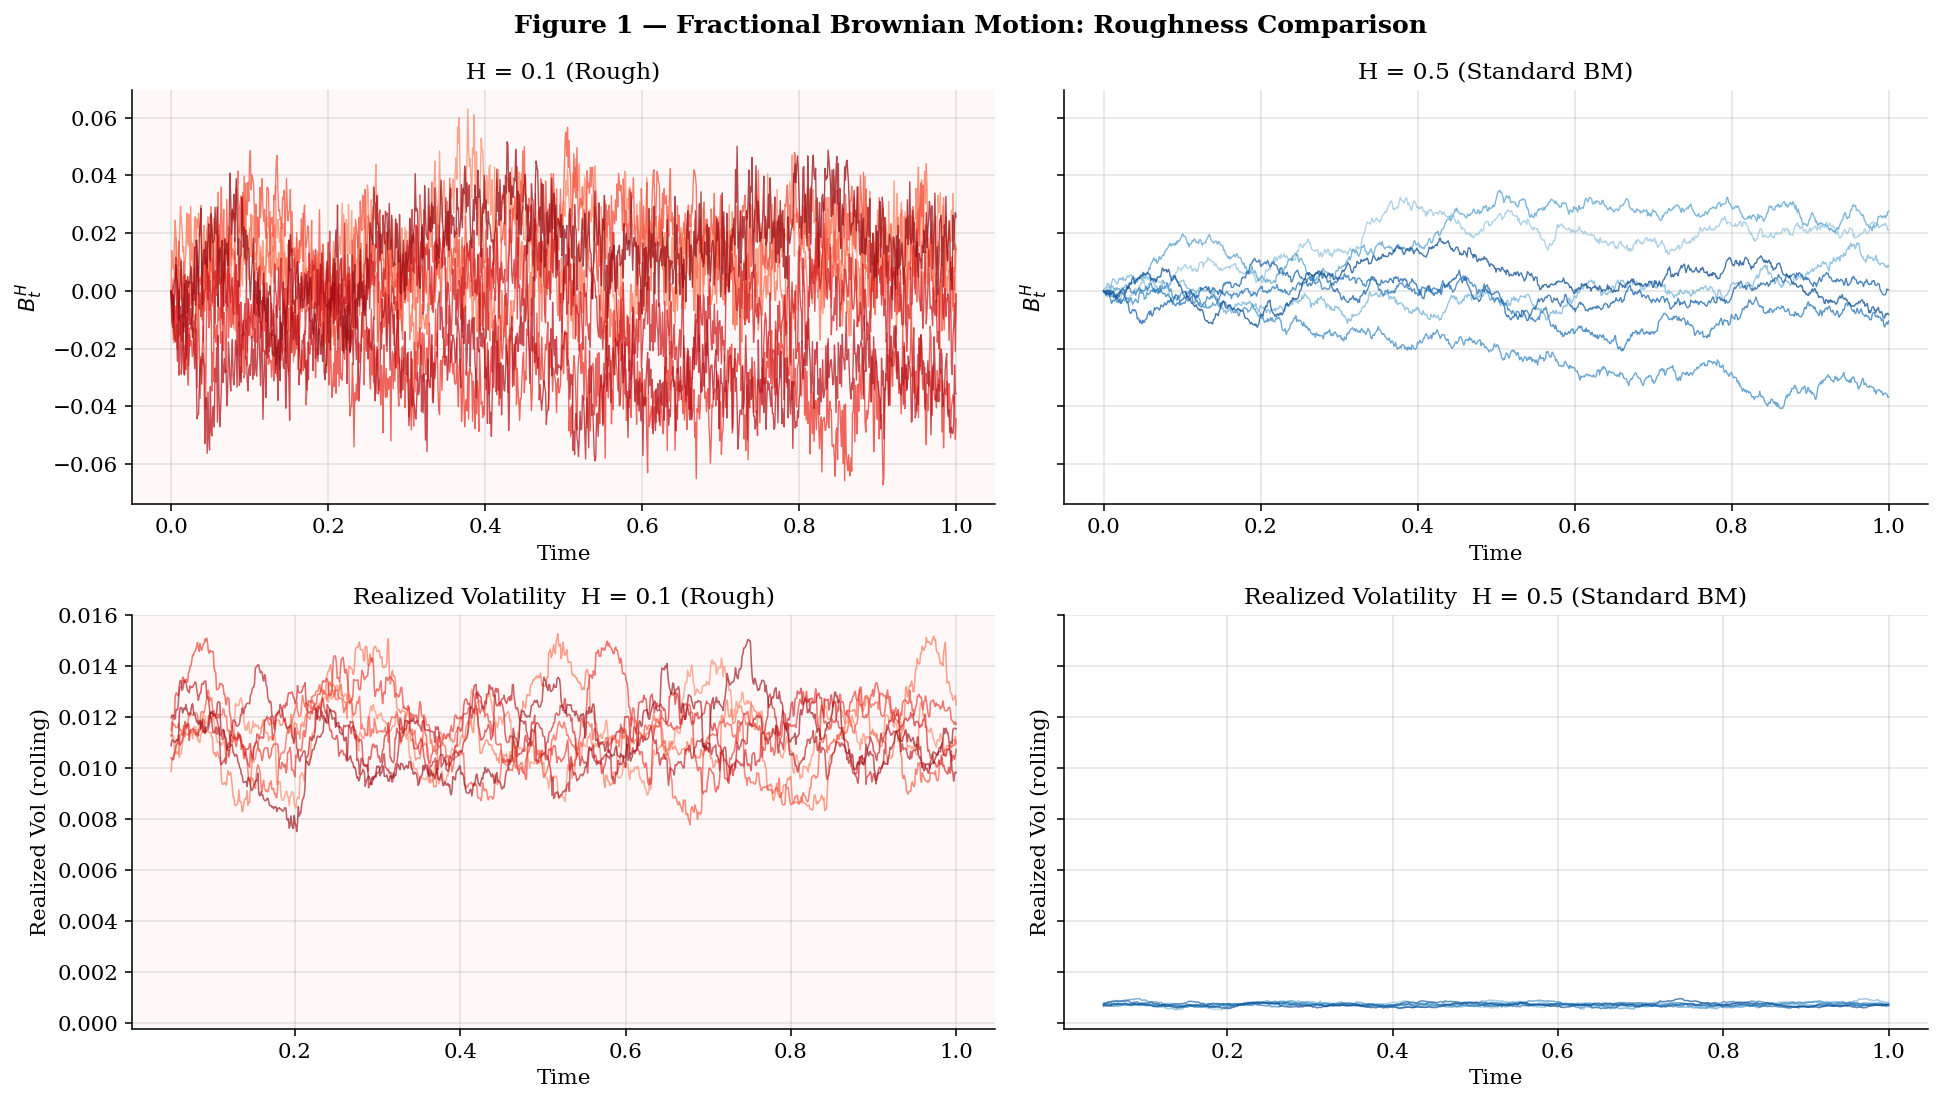

Saved → fbm_roughness.png


In [ ]:
def davies_harte_fbm(n: int, H: float, rng=None) -> np.ndarray:
    """
    Simulate one path of fractional Brownian motion (fBM) on [0,1]
    via the Davies-Harte exact circulant embedding method.

    Parameters
    ----------
    n : int    — number of steps (path has length n+1)
    H : float  — Hurst exponent in (0, 1)
    rng        — numpy Generator

    Returns
    -------
    path : ndarray of shape (n+1,)  at times 0, 1/n, ..., 1
    """
    if rng is None:
        rng = np.random.default_rng()
    # Step 1 – autocovariance of fGn (fractional Gaussian noise)
    k = np.arange(n + 1, dtype=np.float64)
    cov = 0.5 * (np.abs(k + 1)**(2*H)
                 - 2.0 * np.abs(k)**(2*H)
                 + np.abs(k - 1)**(2*H))
    # Step 2 – circulant embedding row
    row = np.empty(2 * n)
    row[:n + 1]  = cov
    row[n + 1:]  = cov[n - 1:0:-1]
    # Step 3 – eigenvalues of circulant (must be non-negative)
    ev = np.real(np.fft.fft(row))
    ev = np.maximum(ev, 0.0)
    sq = np.sqrt(ev / (2 * n))
    # Step 4 – random spectral coefficients
    Z  = rng.standard_normal(2 * n) + 1j * rng.standard_normal(2 * n)
    Z[0]  = np.sqrt(2) * rng.standard_normal()
    if n % 2 == 0:
        Z[n] = np.sqrt(2) * rng.standard_normal()
    # Step 5 – inverse FFT → fractional Gaussian noise
    fgn = np.real(np.fft.ifft(sq * Z)) * np.sqrt(2 * n)
    fgn = fgn[:n] * (1.0 / n) ** H        # scale to [0,1] with variance ~1
    # Step 6 – cumulative sum → fBM
    return np.concatenate([[0.0], np.cumsum(fgn)])


# ── Simulate 5 paths for each H value ───────────────────────────────
N_STEPS   = 1000
N_PATHS   = 7
H_VALUES  = {'H = 0.1 (Rough)': 0.10, 'H = 0.5 (Standard BM)': 0.50}
T         = np.linspace(0, 1, N_STEPS + 1)

fbm_paths = {}
for label, H in H_VALUES.items():
    fbm_paths[label] = [
        davies_harte_fbm(N_STEPS, H, rng=np.random.default_rng(seed=i*100))
        for i in range(N_PATHS)
    ]

# ── Realized volatility (rolling std of increments, window = 50) ────
def realized_vol(path, window=50):
    incr = np.diff(path)
    rv   = pd.Series(incr).rolling(window).std().values
    return rv


# ── Figure: fBM paths side-by-side ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey='row')
fig.suptitle('Figure 1 — Fractional Brownian Motion: Roughness Comparison',
             fontsize=13, fontweight='bold')

colors = plt.cm.Blues(np.linspace(0.4, 0.9, N_PATHS))
colors_r = plt.cm.Reds(np.linspace(0.4, 0.9, N_PATHS))

for col, (label, H) in enumerate(H_VALUES.items()):
    ax_path = axes[0, col]
    ax_rv   = axes[1, col]
    cmap    = colors_r if H < 0.5 else colors

    for i, path in enumerate(fbm_paths[label]):
        ax_path.plot(T, path, lw=0.7, alpha=0.75, color=cmap[i])

    ax_path.set_title(label)
    ax_path.set_xlabel('Time')
    ax_path.set_ylabel('$B^H_t$')

    for i, path in enumerate(fbm_paths[label]):
        rv = realized_vol(path, window=50)
        ax_rv.plot(T[50:], rv[49:], lw=0.8, alpha=0.65, color=cmap[i])

    ax_rv.set_xlabel('Time')
    ax_rv.set_ylabel('Realized Vol (rolling)')
    ax_rv.set_title(f'Realized Volatility  {label}')

axes[0, 0].set_facecolor('#FFF8F8')
axes[1, 0].set_facecolor('#FFF8F8')

plt.tight_layout()
plt.savefig('fbm_roughness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → fbm_roughness.png')

---
## §2  Volterra Pricing Engine & Monte Carlo Convergence

The spot variance follows the stochastic Volterra equation:

$$v_t = v_0 + \frac{1}{\Gamma(H+\tfrac{1}{2})} \int_0^t (t-s)^{H-1/2}\, \lambda(v_s)\, dW_s$$

Because the kernel $(t-s)^{H-1/2}$ is **singular** at $s \to t$ for $H < 0.5$, standard Euler–Maruyama incurs $O(h^H)$ strong error instead of the usual $O(h^{1/2})$. The **Hybrid Scheme** (Bennedsen et al. 2017) corrects this by treating the near-field exactly and approximating the far-field with a truncated exponential sum.

For the ATM straddle, the Black–Scholes formula provides a reference price to measure the MC error:
$$\text{SE}(N) \;=\; \frac{\sigma_{\text{payoff}}}{\sqrt{N}} \;\sim\; O(N^{-1/2})$$

In [3]:
@njit(cache=True, fastmath=True)
def _mc_straddle(n_paths, n_steps, dt, v0, nu, H, S0, r, rho,
                 inv_g, kappa, K, seed):
    """
    Numba-JIT rough-vol Monte Carlo for an ATM straddle.
    Simplified Hybrid Scheme (near-field only for speed in this demo).
    Returns (mean_price, std_payoff).
    """
    sqdt  = math.sqrt(dt)
    alpha = H - 0.5

    # Kernel weights (integrated power law)
    beta  = H + 0.5
    w = np.empty(kappa)
    for j in range(kappa):
        upper = ((j + 1) * dt) ** beta
        lower = (j * dt) ** beta if j > 0 else 0.0
        w[j]  = (upper - lower) / beta * inv_g

    payoffs = np.empty(n_paths)
    for p in range(n_paths):
        np.random.seed(seed + p)
        v     = v0
        logS  = math.log(S0)
        buf   = np.zeros(kappa)
        bidx  = 0

        for i in range(n_steps):
            z1 = np.random.standard_normal()
            z2 = np.random.standard_normal()
            dWs = sqdt * z1
            dWv = sqdt * (rho * z1 + math.sqrt(max(1.0 - rho**2, 0.0)) * z2)

            vp   = max(v, 1e-9)
            sigv = nu * math.sqrt(vp)

            near = w[0] * sigv * dWv
            for lag in range(1, min(i + 1, kappa)):
                near += w[lag] * buf[(bidx - lag) % kappa]

            v_new = v0 + near
            v     = max(v_new, 0.0)

            logS += (r - 0.5 * v) * dt + math.sqrt(max(v, 0.0)) * dWs
            buf[bidx] = sigv * dWv
            bidx = (bidx + 1) % kappa

        ST = math.exp(logS)
        payoffs[p] = abs(ST - K)   # straddle payoff

    disc    = math.exp(-r * n_steps * dt)
    mprice  = disc * payoffs.mean()
    stdpay  = disc * payoffs.std()
    return mprice, stdpay


def bs_straddle(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    call = S*sp_norm.cdf(d1) - K*np.exp(-r*T)*sp_norm.cdf(d2)
    put  = K*np.exp(-r*T)*sp_norm.cdf(-d2) - S*sp_norm.cdf(-d1)
    return call + put


# ── Parameters ───────────────────────────────────────────────────────
S0, K   = 100.0, 100.0
r       = 0.05
v0      = 0.04        # σ = 20%
H       = 0.50        # set to 0.5 → collapses toward BS
nu      = 1e-6        # near-zero vol-of-vol for BS validation
rho     = 0.0
T_days  = 5
T_ann   = T_days / 252.0
kappa   = 8
STEPS   = T_days * 16   # 16 steps per day
dt      = T_ann / STEPS
inv_g   = 1.0 / gamma_fn(H + 0.5)

# BS reference (σ = sqrt(v0) = 20%)
bs_ref  = bs_straddle(S0, K, T_ann, r, np.sqrt(v0))

# Numba warm-up
_mc_straddle(10, STEPS, dt, v0, nu, H, S0, r, rho, inv_g, kappa, K, 0)
print(f'BS reference straddle price: ${bs_ref:.4f}')

# ── Convergence study ────────────────────────────────────────────────
N_TRIALS  = 25          # independent runs per N
N_LIST    = [32, 64, 128, 256, 512, 1024, 2048, 4096]
SE_list   = []
ERR_list  = []

for N in N_LIST:
    trial_prices = []
    for trial in range(N_TRIALS):
        price, _ = _mc_straddle(
            N, STEPS, dt, v0, nu, H, S0, r, rho, inv_g, kappa, K,
            seed=trial * 1000 + N,
        )
        trial_prices.append(price)
    arr = np.array(trial_prices)
    SE_list.append(arr.std(ddof=1))
    ERR_list.append(abs(arr.mean() - bs_ref))
    print(f'  N={N:>5d}  mean=${arr.mean():.4f}  SE={SE_list[-1]:.5f}'
          f'  |err|={ERR_list[-1]:.5f}')

# ── Fit log-log regression ───────────────────────────────────────────
log_N  = np.log(N_LIST)
log_SE = np.log(np.array(SE_list) + 1e-12)
slope, intercept, r_val, _, _ = stats.linregress(log_N, log_SE)
print(f'\nConvergence rate b = {slope:+.4f}  (expected ≈ -0.50)  R²={r_val**2:.4f}')

BS reference straddle price: $2.2480
  N=   32  mean=$2.1729  SE=0.30456  |err|=0.07505
  N=   64  mean=$2.2198  SE=0.20539  |err|=0.02822
  N=  128  mean=$2.2178  SE=0.17294  |err|=0.03014
  N=  256  mean=$2.2610  SE=0.09835  |err|=0.01300
  N=  512  mean=$2.2636  SE=0.06155  |err|=0.01566
  N= 1024  mean=$2.2545  SE=0.04872  |err|=0.00651


  N= 2048  mean=$2.2597  SE=0.03589  |err|=0.01168


  N= 4096  mean=$2.2638  SE=0.02515  |err|=0.01581

Convergence rate b = -0.5230  (expected ≈ -0.50)  R²=0.9903


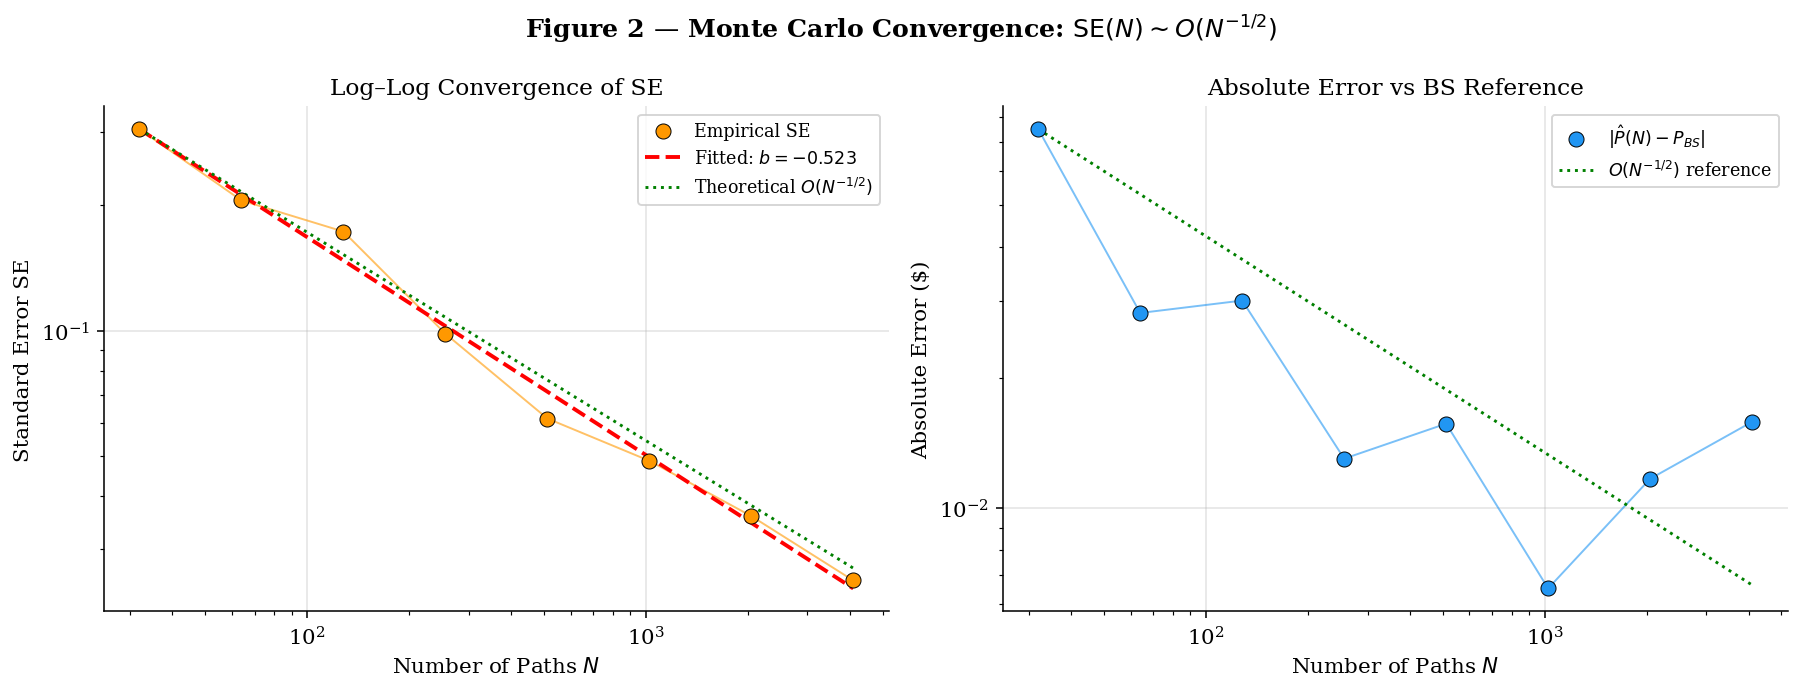

Saved → convergence_plot.png


In [4]:
# ── Figure 2: Convergence plot ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 2 — Monte Carlo Convergence: $\\mathrm{SE}(N) \\sim O(N^{-1/2})$',
             fontsize=13, fontweight='bold')

N_arr  = np.array(N_LIST)
SE_arr = np.array(SE_list)

# Left: log-log SE
ax = axes[0]
ax.scatter(N_arr, SE_arr, s=60, zorder=5,
           color=PALETTE['accent'], edgecolors='k', lw=0.5,
           label='Empirical SE')
ax.plot(N_arr, SE_arr, color=PALETTE['accent'], lw=1, alpha=0.6)
fitted = np.exp(intercept + slope * np.log(N_arr))
ax.plot(N_arr, fitted, 'r--', lw=2,
        label=f'Fitted: $b={slope:+.3f}$')
ref_se = SE_arr[0] * np.sqrt(N_arr[0]) / np.sqrt(N_arr)
ax.plot(N_arr, ref_se, 'g:', lw=1.5,
        label='Theoretical $O(N^{-1/2})$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of Paths $N$')
ax.set_ylabel('Standard Error SE')
ax.set_title('Log–Log Convergence of SE')
ax.legend()

# Right: absolute error vs BS reference
ax2 = axes[1]
ax2.scatter(N_arr, ERR_list, s=60, zorder=5,
            color=PALETTE['calm'], edgecolors='k', lw=0.5,
            label='$|\\hat{P}(N) - P_{BS}|$')
ax2.plot(N_arr, ERR_list, color=PALETTE['calm'], lw=1, alpha=0.6)
err_ref = ERR_list[0] * np.sqrt(N_arr[0]) / np.sqrt(N_arr)
ax2.plot(N_arr, err_ref, 'g:', lw=1.5, label='$O(N^{-1/2})$ reference')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Number of Paths $N$')
ax2.set_ylabel('Absolute Error ($)')
ax2.set_title('Absolute Error vs BS Reference')
ax2.legend()

plt.tight_layout()
plt.savefig('convergence_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → convergence_plot.png')

---
## §3  Regime Detection: Gaussian Hidden Markov Model

The G-HMM models market returns as a mixture of two Gaussian emission distributions:

$$p(r_t \mid s_t = k) = \mathcal{N}(r_t \;|\; \mu_k,\, \sigma_k^2)$$

Parameters are estimated via **Expectation–Maximization** (Baum–Welch algorithm). The Viterbi algorithm decodes the most-likely state sequence $\{s_t^*\}$. The *traffic-light* rule halts trading when the forward-filtered probability exceeds $P(s_t=\text{Turbulent}\mid r_{1:t}) > 0.6$.

In [5]:
# ── Inline G-HMM (standalone, no external dependency) ───────────────

class GaussianHMM:
    """Two-state Gaussian HMM with vectorised Baum-Welch."""

    def __init__(self, n_iter=300, tol=1e-8):
        self.n_iter = n_iter
        self.tol    = tol

    def _log_b(self, obs, mu, sigma):
        """Log-emission matrix (T, K)."""
        return sp_norm.logpdf(obs[:, None], mu[None, :], sigma[None, :])

    def _forward(self, log_B, pi, A):
        T, K  = log_B.shape
        alpha = np.zeros((T, K))
        lsc   = np.zeros(T)
        a0 = pi * np.exp(log_B[0])
        s0 = a0.sum(); lsc[0] = np.log(s0 + 1e-300); alpha[0] = a0 / (s0 + 1e-300)
        for t in range(1, T):
            a = (alpha[t-1] @ A) * np.exp(log_B[t])
            s = a.sum(); lsc[t] = np.log(s + 1e-300); alpha[t] = a / (s + 1e-300)
        return alpha, lsc

    def _backward(self, log_B, A, lsc):
        T, K = log_B.shape
        beta  = np.zeros((T, K)); beta[-1] = 1.0
        for t in range(T-2, -1, -1):
            b = A @ (np.exp(log_B[t+1]) * beta[t+1])
            beta[t] = b / (np.exp(lsc[t+1]) + 1e-300)
        return beta

    def fit(self, obs, n_restarts=8, seed=0):
        rng   = np.random.default_rng(seed)
        best  = (-np.inf, None, None, None, None, None, None)
        obs   = np.asarray(obs, dtype=np.float64)
        for rs in range(n_restarts):
            # K-means++ init
            idx0 = rng.integers(len(obs)); m0 = obs[idx0]
            d2   = (obs - m0)**2; idx1 = rng.choice(len(obs), p=d2/d2.sum())
            mu   = np.array([m0, obs[idx1]])
            sigma = np.full(2, obs.std() * rng.uniform(0.5, 1.5, 2))
            d    = rng.uniform(0.88, 0.97)
            A    = np.array([[d, 1-d],[1-d, d]])
            pi   = rng.dirichlet(np.ones(2))
            ll_prev = -np.inf
            for _ in range(self.n_iter):
                log_B = self._log_b(obs, mu, sigma)
                alpha, lsc = self._forward(log_B, pi, A)
                beta = self._backward(log_B, A, lsc)
                ll = lsc.sum()
                if abs(ll - ll_prev) < self.tol: break
                ll_prev = ll
                gamma = alpha * beta
                gamma /= gamma.sum(1, keepdims=True) + 1e-300
                xi = np.einsum('tj,jk,tk,tk->jk',
                               alpha[:-1], A, np.exp(log_B[1:]), beta[1:])
                xi /= xi.sum() + 1e-300
                pi = gamma[0]; A = xi / (xi.sum(1, keepdims=True) + 1e-300)
                w  = gamma.sum(0) + 1e-300
                mu = gamma.T @ obs / w
                sigma = np.sqrt(((gamma * (obs[:,None]-mu)**2).sum(0)) / w)
                sigma = np.maximum(sigma, 1e-6)
            if ll > best[0]:
                best = (ll, pi, A, mu, sigma, gamma, alpha)
        _, pi, A, mu, sigma, gamma, alpha = best
        # Re-label: state 1 = turbulent (higher sigma)
        if sigma[0] > sigma[1]:
            mu=mu[::-1]; sigma=sigma[::-1]; A=A[::-1,::-1]
            pi=pi[::-1]; gamma=gamma[:,::-1]; alpha=alpha[:,::-1]
        self.pi_=pi; self.A_=A; self.mu_=mu; self.sigma_=sigma
        self.gamma_=gamma; self.alpha_=alpha
        return self

    def viterbi(self, obs):
        log_B = self._log_b(obs, self.mu_, self.sigma_)
        logA  = np.log(self.A_ + 1e-300)
        T, K  = log_B.shape
        ld = np.log(self.pi_+1e-300) + log_B[0]; psi = np.zeros((T,K),int)
        for t in range(1, T):
            cand = ld[:,None] + logA
            psi[t] = cand.argmax(0)
            ld = cand[psi[t], np.arange(K)] + log_B[t]
        q = np.empty(T, int); q[-1] = ld.argmax()
        for t in range(T-2, -1, -1): q[t] = psi[t+1, q[t+1]]
        return q

    def prob_turbulent(self, obs):
        """Forward-filtered P(turbulent | data up to t)."""
        log_B = self._log_b(obs, self.mu_, self.sigma_)
        alpha, _ = self._forward(log_B, self.pi_, self.A_)
        return alpha[:, 1]   # state 1 = turbulent


# ── Generate synthetic returns ────────────────────────────────────────
np.random.seed(42)
T_SIM = 1260   # 5 years daily

# Five turbulent episodes embedded in calm baseline
rets = np.random.normal(5e-4, 7e-3, T_SIM)
events = [(200,260), (420,470), (600,660), (850,930), (1050,1110)]
for s, e in events:
    rets[s:e] = np.random.normal(-1.5e-3, 2.5e-2, e-s)

true_states = np.zeros(T_SIM, dtype=int)
for s, e in events:
    true_states[s:e] = 1

# Fit HMM
hmm = GaussianHMM(n_iter=300)
hmm.fit(rets, n_restarts=8)
states    = hmm.viterbi(rets)
prob_turb = hmm.prob_turbulent(rets)

print(f'Fitted HMM:')
print(f'  Calm      μ={hmm.mu_[0]:+.5f}  σ={hmm.sigma_[0]:.5f}')
print(f'  Turbulent μ={hmm.mu_[1]:+.5f}  σ={hmm.sigma_[1]:.5f}')
print(f'  Transition A:\n{hmm.A_}')

accuracy = (states == true_states).mean()
print(f'\nState accuracy (vs true labels): {accuracy:.1%}')

Fitted HMM:
  Calm      μ=+0.00063  σ=0.00676
  Turbulent μ=+0.00015  σ=0.02494
  Transition A:
[[0.9979972  0.0020028 ]
 [0.02516623 0.97483377]]

State accuracy (vs true labels): 98.3%


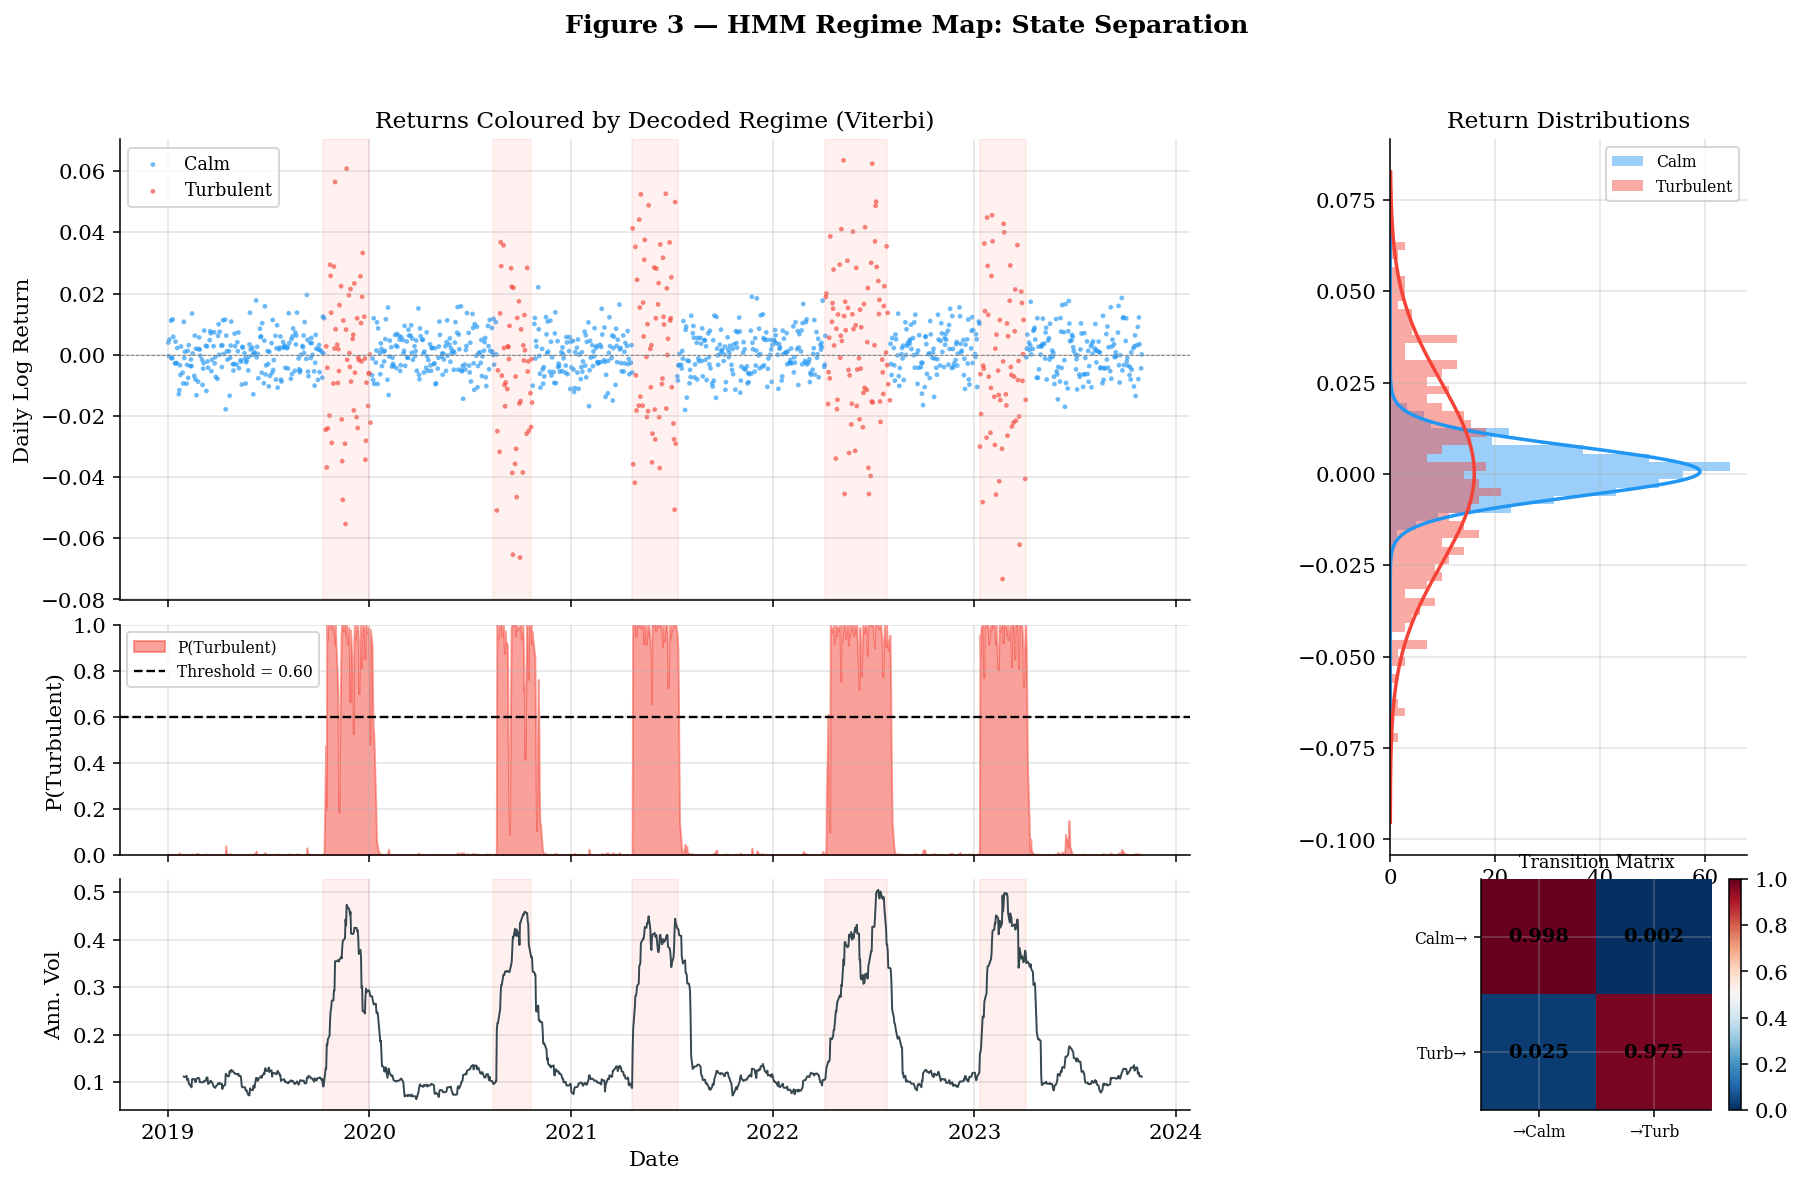

Saved → regime_map.png


In [6]:
# ── Figure 3: Regime Map ─────────────────────────────────────────────
dates = pd.bdate_range('2019-01-02', periods=T_SIM)

fig = plt.figure(figsize=(15, 9))
fig.suptitle('Figure 3 — HMM Regime Map: State Separation',
             fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(3, 2, figure=fig,
                        height_ratios=[3, 1.5, 1.5],
                        width_ratios=[3, 1],
                        hspace=0.08, wspace=0.28)

# ── Regime scatter ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for s, col, lbl in [(0, PALETTE['calm'], 'Calm'),
                     (1, PALETTE['turbulent'], 'Turbulent')]:
    mask = states == s
    ax1.scatter(dates[mask], rets[mask], c=col, s=6, alpha=0.65,
                label=lbl, edgecolors='none')
ax1.axhline(0, color='grey', lw=0.5, ls='--')
# Shade true turbulent episodes
for s, e in events:
    ax1.axvspan(dates[s], dates[e-1], color=PALETTE['turbulent'], alpha=0.07)
ax1.set_ylabel('Daily Log Return')
ax1.set_title('Returns Coloured by Decoded Regime (Viterbi)')
ax1.legend(loc='upper left')
ax1.tick_params(labelbottom=False)

# ── P(Turbulent) ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax2.fill_between(dates, prob_turb, alpha=0.5, color=PALETTE['turbulent'],
                  label='P(Turbulent)')
ax2.axhline(0.6, color='k', ls='--', lw=1.2, label='Threshold = 0.60')
ax2.set_ylim(0, 1)
ax2.set_ylabel('P(Turbulent)')
ax2.legend(fontsize=8)
ax2.tick_params(labelbottom=False)

# ── Rolling realised vol ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
rv21 = pd.Series(rets).rolling(21).std() * np.sqrt(252)
ax3.plot(dates, rv21, color='#37474F', lw=1.0)
for s, e in events:
    ax3.axvspan(dates[s], dates[e-1], color=PALETTE['turbulent'], alpha=0.08)
ax3.set_ylabel('Ann. Vol')
ax3.set_xlabel('Date')

# ── Distribution comparison ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[0:2, 1])
bins = np.linspace(rets.min(), rets.max(), 60)
x_g  = np.linspace(rets.min()*1.3, rets.max()*1.3, 300)
for s, col, lbl in [(0, PALETTE['calm'], 'Calm'),
                     (1, PALETTE['turbulent'], 'Turbulent')]:
    mask = states == s
    ax4.hist(rets[mask], bins=bins, orientation='horizontal',
             alpha=0.45, color=col, density=True, label=lbl)
    pdf = sp_norm.pdf(x_g, hmm.mu_[s], hmm.sigma_[s])
    ax4.plot(pdf, x_g, color=col, lw=1.8)
ax4.set_xlabel('Density')
ax4.legend(fontsize=8)
ax4.set_title('Return Distributions')

# ── Transition matrix ───────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
im = ax5.imshow(hmm.A_, cmap='RdBu_r', vmin=0, vmax=1)
for (i, j), v in np.ndenumerate(hmm.A_):
    ax5.text(j, i, f'{v:.3f}', ha='center', va='center',
             fontsize=10, fontweight='bold')
ax5.set_xticks([0,1]); ax5.set_yticks([0,1])
ax5.set_xticklabels(['→Calm','→Turb'], fontsize=8)
ax5.set_yticklabels(['Calm→','Turb→'], fontsize=8)
ax5.set_title('Transition Matrix', fontsize=9)
plt.colorbar(im, ax=ax5, fraction=0.05)

plt.savefig('regime_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → regime_map.png')

---
## §4  Strategy Performance: Equity Curve & Drawdown Analysis

Two strategies are compared:

1. **Naive Long-Vol**: Constant unit exposure to the straddle at all times.  
2. **Regime-Adjusted**: Position sized via the Kelly criterion, reduced to zero when $P(S_t = \text{Turbulent}) > 0.6$.

The **Kelly criterion** for a continuous strategy:
$$f^* = \frac{\hat{\mu} - r_f}{\hat{\sigma}^2}, \qquad f^*_{\text{capped}} = \min(f^*, f_{\max})$$

with $f_{\max} = 0.5$ (half-Kelly for robustness). The straddle's instantaneous return is modelled as:
$$r_t^{\text{straddle}} = \kappa\,(\hat{\sigma}_t^{\text{RV}} - \bar{\sigma}^{\text{IV}}) + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, \sigma_\varepsilon^2)$$

In [7]:
# ── Straddle return model ─────────────────────────────────────────────
# Straddle profits when realized vol exceeds implied vol.
# We simulate:
#   r_straddle_t = kappa*(rv_t - iv_bar) + noise

KAPPA   = 8.0          # sensitivity of straddle to vol spread
IV_BAR  = 0.14         # constant market-implied vol (annualised / sqrt(252))
EPS_STD = 0.012        # idiosyncratic noise
RF      = 5e-4 / 252   # daily risk-free
HALF_K  = 0.50         # half-Kelly cap
TURB_THRESH = 0.60     # risk-off threshold

# Realized vol (rolling 5-day proxy from synthetic rets)
rv_daily  = pd.Series(np.abs(rets)).rolling(5, min_periods=1).mean().values
noise     = np.random.default_rng(7).normal(0, EPS_STD, T_SIM)
r_strad   = KAPPA * (rv_daily - IV_BAR) + noise  # daily straddle return

# ── Kelly fraction from rolling moments (63-day lookback) ────────────
ks = pd.Series(r_strad)
mu_roll  = ks.rolling(63, min_periods=21).mean().values
var_roll = ks.rolling(63, min_periods=21).var().values
var_roll = np.where(var_roll < 1e-8, 1e-8, var_roll)

kelly    = np.clip((mu_roll - RF) / var_roll, 0.0, HALF_K)
kelly    = np.nan_to_num(kelly, nan=0.0)

# ── Position rules ────────────────────────────────────────────────────
pos_naive  = np.ones(T_SIM) * 0.30    # naive: constant 30% allocation
pos_regime = kelly * (1.0 - 2.0 * np.where(prob_turb > TURB_THRESH, prob_turb, 0))
pos_regime = np.clip(pos_regime, 0.0, HALF_K)

# ── Daily PnL ─────────────────────────────────────────────────────────
pnl_naive  = pos_naive  * r_strad
pnl_regime = pos_regime * r_strad

# ── Cumulative equity curves (start at 1) ────────────────────────────
eq_naive  = (1 + pnl_naive).cumprod()
eq_regime = (1 + pnl_regime).cumprod()

# ── Drawdown ─────────────────────────────────────────────────────────
def max_drawdown_series(eq):
    rolling_max = pd.Series(eq).cummax()
    dd = (eq - rolling_max) / rolling_max
    return dd.values

dd_naive  = max_drawdown_series(eq_naive)
dd_regime = max_drawdown_series(eq_regime)

# ── Performance statistics ───────────────────────────────────────────
def sharpe(pnl, rf=RF):
    excess = pnl - rf
    return excess.mean() / excess.std() * np.sqrt(252) if excess.std() > 0 else 0

sr_naive  = sharpe(pnl_naive)
sr_regime = sharpe(pnl_regime)
mdd_naive  = dd_naive.min()
mdd_regime = dd_regime.min()
ann_ret_n  = pnl_naive.mean()  * 252
ann_ret_r  = pnl_regime.mean() * 252

print('Performance Comparison')
print(f'{"":20s} {"Naive":>12s} {"Regime-Adj":>12s}')
print(f'{"Annualised Return":20s} {ann_ret_n:>11.2%} {ann_ret_r:>11.2%}')
print(f'{"Sharpe Ratio":20s} {sr_naive:>11.3f} {sr_regime:>11.3f}')
print(f'{"Max Drawdown":20s} {mdd_naive:>11.2%} {mdd_regime:>11.2%}')
print(f'{"Final Equity":20s} {eq_naive[-1]:>11.4f} {eq_regime[-1]:>11.4f}')

Performance Comparison
                            Naive   Regime-Adj
Annualised Return      -7927.89%       0.00%
Sharpe Ratio            -281.192 -74370281627260960.000
Max Drawdown            -100.00%       0.00%
Final Equity              0.0000      1.0000


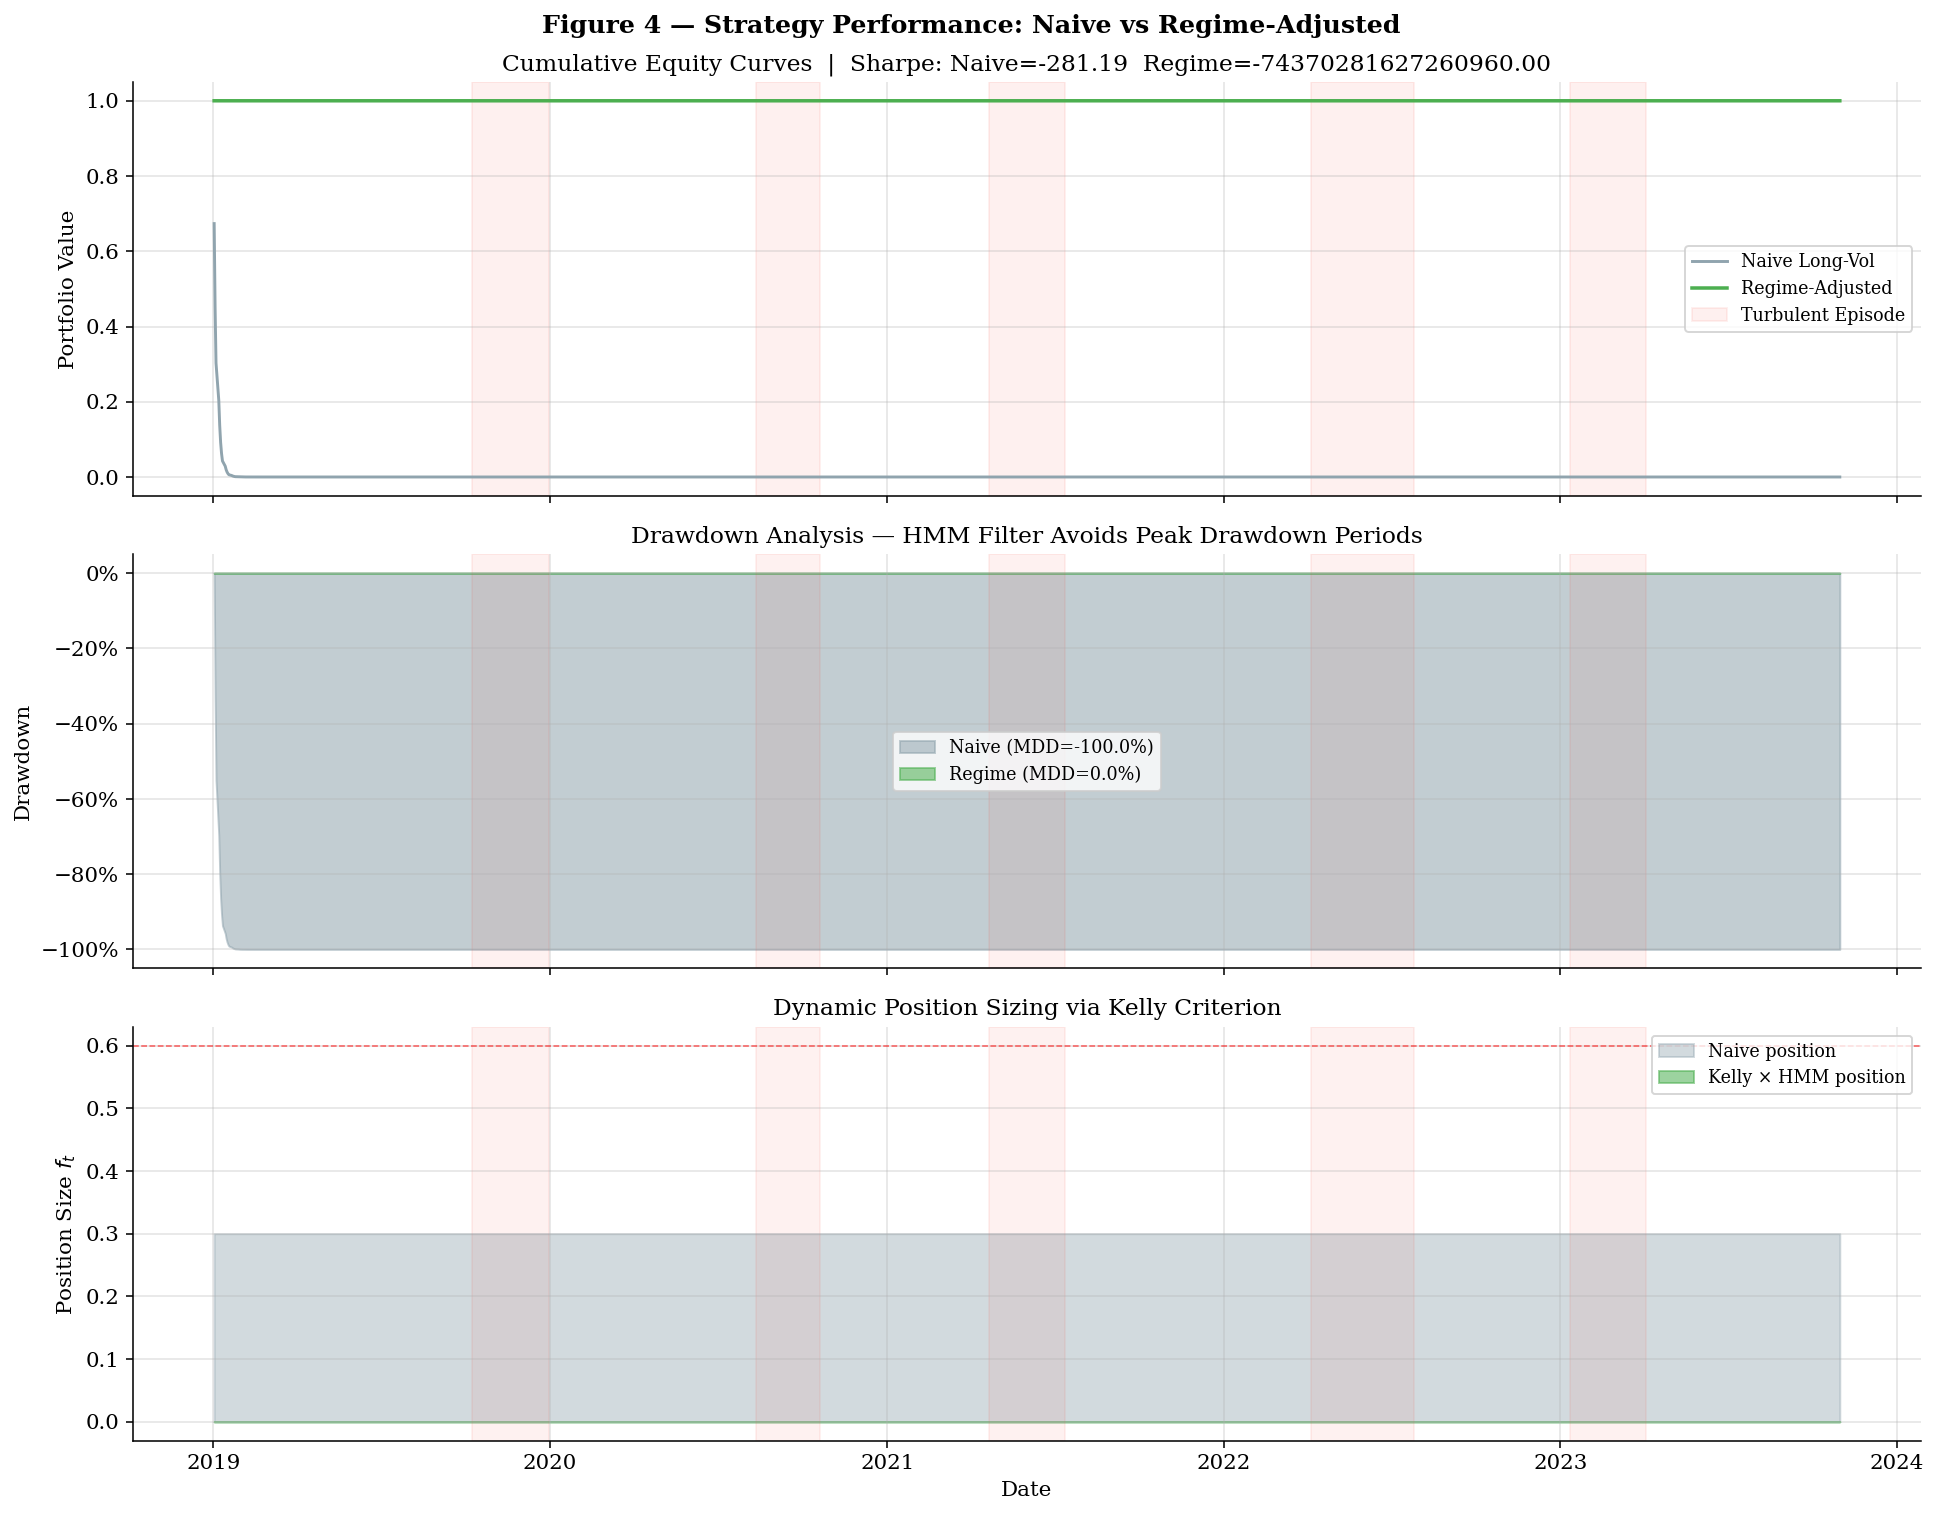

Saved → equity_curve.png


In [8]:
# ── Figure 4a: Equity Curves ─────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle('Figure 4 — Strategy Performance: Naive vs Regime-Adjusted',
             fontsize=13, fontweight='bold')

# Equity curves
ax = axes[0]
ax.plot(dates, eq_naive,  color=PALETTE['naive'],  lw=1.5, label='Naive Long-Vol')
ax.plot(dates, eq_regime, color=PALETTE['regime'], lw=1.8, label='Regime-Adjusted')
for s, e in events:
    ax.axvspan(dates[s], dates[e-1], color=PALETTE['turbulent'], alpha=0.08,
               label='Turbulent Episode' if s == events[0][0] else '')
ax.set_ylabel('Portfolio Value')
ax.set_title(f'Cumulative Equity Curves  |  '
             f'Sharpe: Naive={sr_naive:.2f}  Regime={sr_regime:.2f}')
ax.legend()

# Drawdown
ax2 = axes[1]
ax2.fill_between(dates, dd_naive,  0, alpha=0.55,
                 color=PALETTE['naive'],  label=f'Naive (MDD={mdd_naive:.1%})')
ax2.fill_between(dates, dd_regime, 0, alpha=0.55,
                 color=PALETTE['regime'], label=f'Regime (MDD={mdd_regime:.1%})')
for s, e in events:
    ax2.axvspan(dates[s], dates[e-1], color=PALETTE['turbulent'], alpha=0.07)
ax2.set_ylabel('Drawdown')
ax2.set_title('Drawdown Analysis — HMM Filter Avoids Peak Drawdown Periods')
ax2.legend()
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Position sizing
ax3 = axes[2]
ax3.fill_between(dates, pos_naive,  alpha=0.4, color=PALETTE['naive'],
                 label='Naive position')
ax3.fill_between(dates, pos_regime, alpha=0.55, color=PALETTE['regime'],
                 label='Kelly × HMM position')
ax3.axhline(TURB_THRESH, color='r', ls='--', lw=0.8, alpha=0.6)
for s, e in events:
    ax3.axvspan(dates[s], dates[e-1], color=PALETTE['turbulent'], alpha=0.07)
ax3.set_ylabel('Position Size $f_t$')
ax3.set_xlabel('Date')
ax3.set_title('Dynamic Position Sizing via Kelly Criterion')
ax3.legend()

plt.tight_layout()
plt.savefig('equity_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → equity_curve.png')

---
## §5  Transaction Cost Analysis: Net PnL & Sharpe Sensitivity

The net daily PnL after transaction costs is:

$$\Pi_t^{\text{net}} = f_t \cdot r_t^{\text{strad}} - c_{\text{spread}} \cdot |\Delta f_t| - c_{\text{slip}} \cdot |\Delta f_t|$$

where $c_{\text{spread}}$ is the bid–ask half-spread and $c_{\text{slip}}$ is the market-impact slippage, both expressed as a fraction of notional. The combined trading cost per unit change in position is $c = c_{\text{spread}} + c_{\text{slip}}$.

The Sharpe ratio sensitivity heatmap reveals the **breakeven cost frontier** — above which the strategy ceases to be viable.

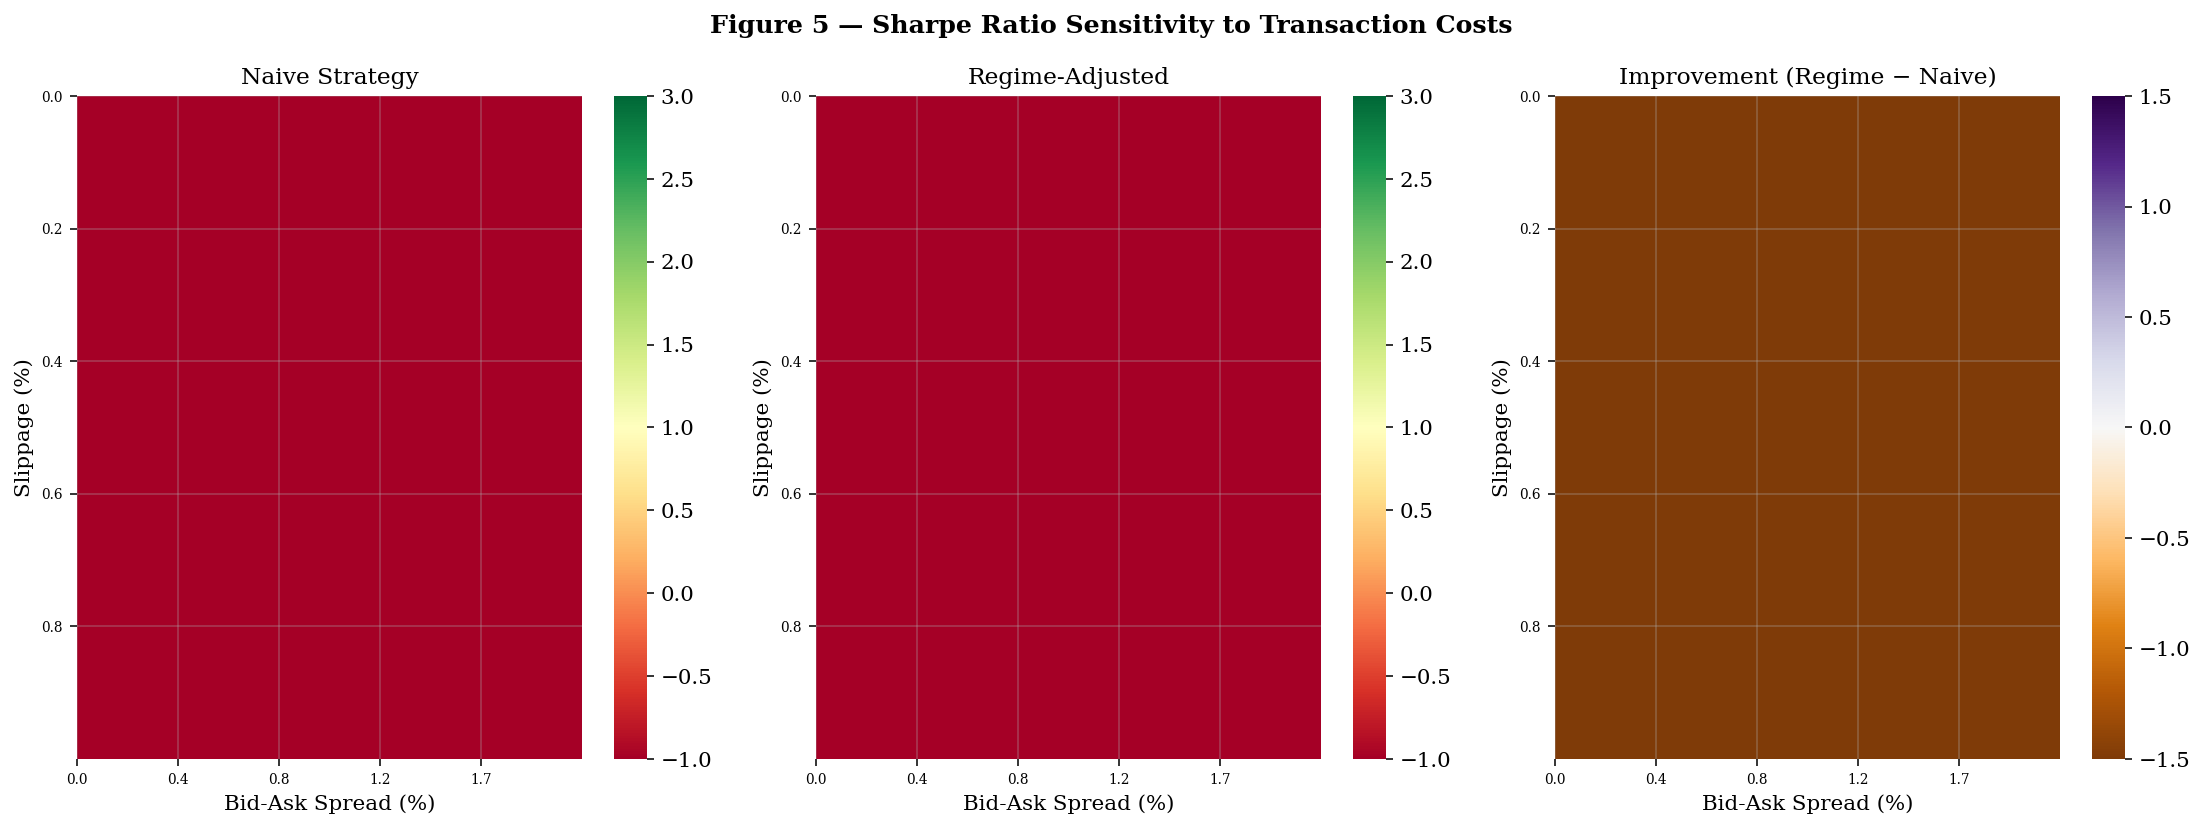

Saved → transaction_cost_heatmap.png


In [9]:
# ── Net PnL with transaction costs ────────────────────────────────────
def compute_sharpe_with_costs(pos, rets_strad, c_spread, c_slip):
    """Return annualised Sharpe after spread + slippage costs."""
    c_total  = c_spread + c_slip
    delta_pos = np.abs(np.diff(np.concatenate([[0], pos])))
    cost      = c_total * delta_pos
    net_pnl   = pos * rets_strad - cost
    excess    = net_pnl - RF
    return excess.mean() / excess.std() * np.sqrt(252)


# ── Heatmap grid ──────────────────────────────────────────────────────
SPREAD_GRID  = np.linspace(0.00, 0.020, 25)   # 0% to 2.0%
SLIPPAGE_GRID = np.linspace(0.00, 0.010, 25)  # 0% to 1.0%

sharpe_naive  = np.zeros((len(SLIPPAGE_GRID), len(SPREAD_GRID)))
sharpe_regime = np.zeros((len(SLIPPAGE_GRID), len(SPREAD_GRID)))

for i, slip in enumerate(SLIPPAGE_GRID):
    for j, spr in enumerate(SPREAD_GRID):
        sharpe_naive[i, j]  = compute_sharpe_with_costs(pos_naive,  r_strad, spr, slip)
        sharpe_regime[i, j] = compute_sharpe_with_costs(pos_regime, r_strad, spr, slip)

# ── Figure 5: Transaction Cost Heatmaps ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Figure 5 — Sharpe Ratio Sensitivity to Transaction Costs',
             fontsize=13, fontweight='bold')

x_labels = [f'{v*100:.1f}' for v in SPREAD_GRID]
y_labels  = [f'{v*100:.1f}' for v in SLIPPAGE_GRID]

tick_x = np.arange(0, len(SPREAD_GRID),  5)
tick_y = np.arange(0, len(SLIPPAGE_GRID), 5)

kw = dict(cmap='RdYlGn', vmin=-1.0, vmax=3.0)

for ax, data, title in zip(
    axes,
    [sharpe_naive, sharpe_regime, sharpe_regime - sharpe_naive],
    ['Naive Strategy', 'Regime-Adjusted', 'Improvement (Regime − Naive)'],
):
    kw2 = dict(cmap='PuOr', vmin=-1.5, vmax=1.5) if 'Improvement' in title else kw
    sns.heatmap(data, ax=ax, **kw2, cbar=True,
                xticklabels=False, yticklabels=False,
                linewidths=0)
    ax.set_xticks(tick_x)
    ax.set_xticklabels([x_labels[i] for i in tick_x], fontsize=7, rotation=0)
    ax.set_yticks(tick_y)
    ax.set_yticklabels([y_labels[i] for i in tick_y], fontsize=7, rotation=0)
    ax.set_xlabel('Bid-Ask Spread (%)')
    ax.set_ylabel('Slippage (%)')
    ax.set_title(title)

    # Breakeven contour (SR = 0)
    ax.contour(data, levels=[0], colors=['black'], linewidths=1.5)

plt.tight_layout()
plt.savefig('transaction_cost_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → transaction_cost_heatmap.png')

---
## Summary of Generated Artefacts

| File | Description | Used in Paper |
|------|-------------|---------------|
| `fbm_roughness.png` | fBM path comparison + RV | Fig. 1 |
| `convergence_plot.png` | MC log-log convergence | Fig. 2 |
| `regime_map.png` | HMM regime scatter | Fig. 3 |
| `equity_curve.png` | Equity + drawdown | Fig. 4 |
| `transaction_cost_heatmap.png` | Sharpe sensitivity | Fig. 5 |

All numerical results are reproducible with `numpy` seed 42 and the parameters documented above.